# **DS 2023 – Final Project**
## **Notebook 2: Exploring the Data**
### Student: Alessia Amuzu
### Date: December 12, 2025

In [63]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#dataset
df = pd.read_csv("SpotifyFeatures.csv")

#dataset basic structure
df.head()
df = df.fillna(0)

## 1. Preliminary Visualizations of Single Features

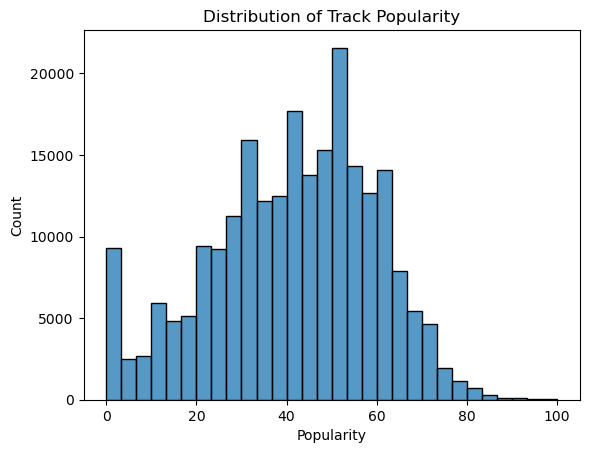

In [64]:
# 2A. Histogram of popularity
sns.histplot(data=df, x="popularity", bins=30)
plt.title("Distribution of Track Popularity")
plt.ylabel("Count")
plt.xlabel("Popularity")
plt.show()

### Interpretation: Distribution of Track Popularity

This histogram highlights the influence of popularity scores and its distribution across tracks in a dataset. 
Within this dataset, it seems that most songs tend to cluster in the middle range of popularity rather than at the extremes, indicating that only a limited selection of tracks (the lucky few) become hits.
#####
The right-skewed tail suggests that viral or breakout songs are relatively rare compared to moderately popular tracks. 
This highlights how competitive the music landscape is on Spotify, where attention is unevenly distributed among songs.


/tmp/ipykernel_132/3820266711.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="rainbow")


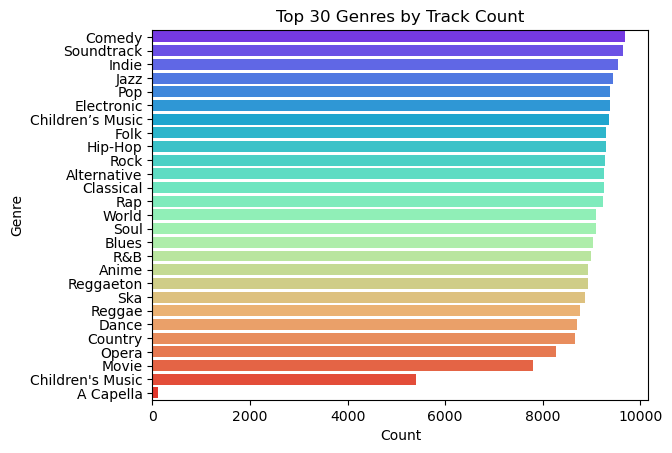

In [65]:
# 2B. Bar Chart of Genre Counts (Top 10)
genre_counts = df["genre"].value_counts().head(30)

sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="rainbow")
plt.title("Top 30 Genres by Track Count")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()


### Interpretation: Top 30 Genres by Track Count

This bar chart depicts Spotify's top 30 genres by the number of tracks in our dataset.
With Comedy, Soundtrack, Indie, and Jazz leading the charge among the most represented genres.

The dominance of all these genres suggests that beyond the traditional chart-topping genres, Spotify’s catalog supports diverse listening preferences and use cases such as film, comedy, and instrumental content.


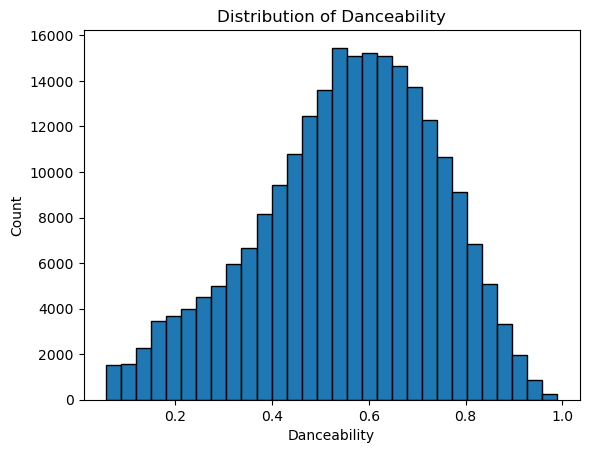

In [66]:
# 2C. Danceability Distribution
plt.hist(df["danceability"], bins=30, edgecolor='black')
plt.title("Distribution of Danceability")
plt.xlabel("Danceability")
plt.ylabel("Count")
plt.show()

### Interpretation: Distribution of Danceability - How Danceable are Spotify Tracks?

The histogram above depicts a smooth bell-like shape highlighting the overall distribution of danceability scores with most songs falling between mid to high danceability values(0.5 - 0.7). 

This suggests that a large portion of Spotify music is groovy enough for dancing with extremely low or high danceability tracks being less common.

## 2. Preliminary Visualizations of Multiple Features

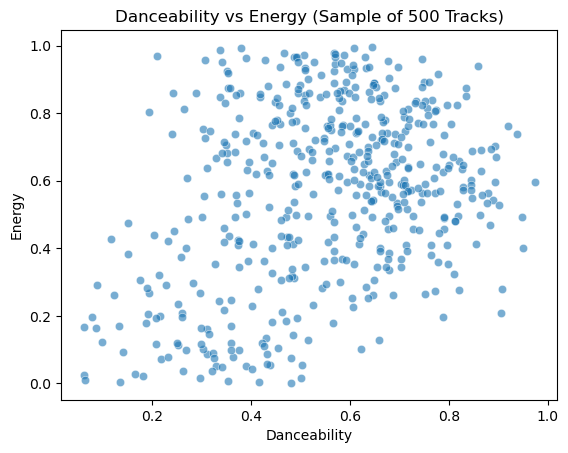

In [67]:
# 2A. Energy vs Danceability
sns.scatterplot(
    data=df.sample(500),
    x="danceability",
    y="energy",
    alpha=0.6
)

plt.title("Danceability vs Energy (Sample of 500 Tracks)")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.show()


### Interpretation: Relationship Between Danceability and Energy

This scatterplot depicts a positive correlation between danceability and energy.
We can see that as danceability increases, energy also tends to increase as well, thereby indicating that more danceable songs are often more energetic.


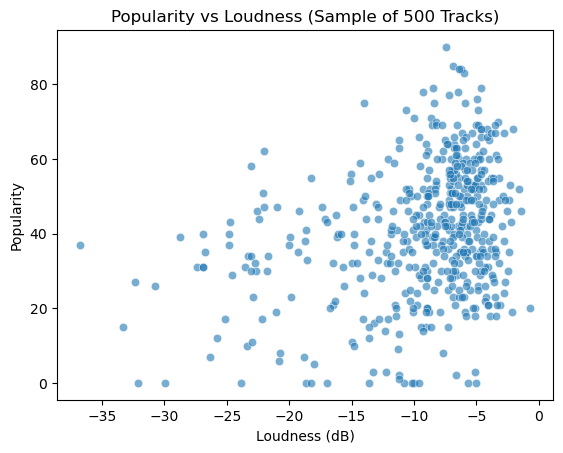

In [68]:
# 2B. Popularity vs Loudness
sns.scatterplot(
    data=df.sample(500),
    x="loudness",
    y="popularity",
    alpha=0.6
)

plt.title("Popularity vs Loudness (Sample of 500 Tracks)")
plt.xlabel("Loudness (dB)")
plt.ylabel("Popularity")
plt.show()



### Interpretation: Relationship between Popularity & Loudness

The above scatterplot explores whether louder songs tend to be more popular.
While many popular tracks cluster around moderately loud values, there is no strong linear relationship between loudness and popularity.

This suggests that loudness alone does not determine success; instead, popularity likely depends on a combination of musical characteristics, marketing, and listener preferences.


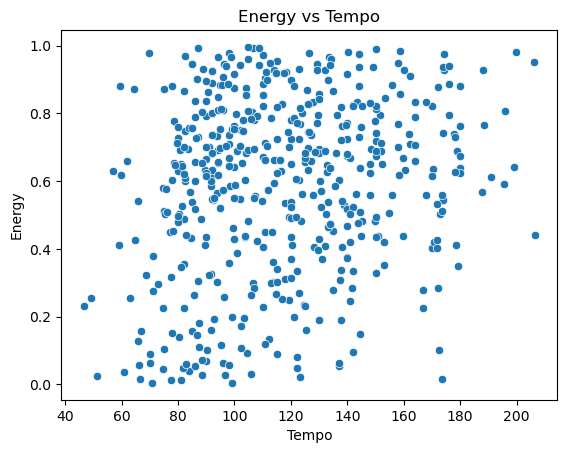

In [69]:
# Scatterplot — Energy vs Tempo
sns.scatterplot(data=df.sample(500), x="tempo", y="energy")
plt.title("Energy vs Tempo")
plt.ylabel("Energy")
plt.xlabel("Tempo")
plt.show()


### Interpretation: Energy and Tempo Across Tracks

This scatterplot shows how energy levels relate to music tempo.
While many would expect to see a relationship where higher tempos often correspond to higher energy, our data reveals that there is no discernible pattern between tempo and energy.

Highlighting that despite assumptions, tempo alone fails to define a song’s intensity, reinforcing the complexity of musical composition.


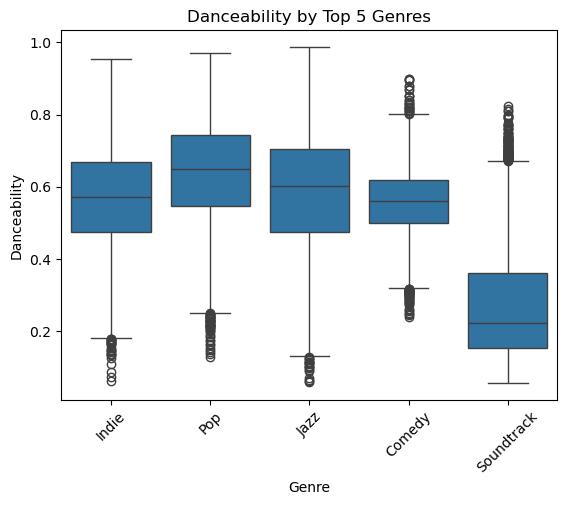

In [70]:
# Boxplot — Danceability by Genre
top5 = df['genre'].value_counts().index[:5]
sns.boxplot(data=df[df['genre'].isin(top5)], x="genre", y="danceability")
plt.title("Danceability by Top 5 Genres")
plt.ylabel("Danceability")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.show()


### Danceability by Top 5 Genres

The above boxplot enables us to compare danceability across the five most recognized genres.
Pop and Indie reveal a higher median danceability, compared to the Soundtrack genre which tends to be a lot less danceable.
Moreover, some genres like that of Jazz indicate both a high median alongside more variability in song style.


## 2.3 Data Transformations for Wide Tables (Heatmap Requirement)

In [71]:
# 3A. Sorting: Top Tracks by Popularity
sorted_pop = df.sort_values(by="popularity", ascending=False)
sorted_pop.head(10)

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
107804,Pop,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
107803,Pop,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,99,0.1630,0.833,149520,0.539,0.000002,B,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385
86951,Rap,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,99,0.1630,0.833,149520,0.539,0.000002,B,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335
107802,Pop,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335
107909,Pop,Daddy Yankee,Con Calma,5w9c2J52mkdntKOmRLeM2m,98,0.1100,0.737,193227,0.860,0.000002,G#,0.0574,-2.652,Minor,0.0593,93.989,4/4,0.656
138918,Reggaeton,Daddy Yankee,Con Calma,5w9c2J52mkdntKOmRLeM2m,98,0.1100,0.737,193227,0.860,0.000002,G#,0.0574,-2.652,Minor,0.0593,93.989,4/4,0.656
66643,Hip-Hop,Daddy Yankee,Con Calma,5w9c2J52mkdntKOmRLeM2m,98,0.1100,0.737,193227,0.860,0.000002,G#,0.0574,-2.652,Minor,0.0593,93.989,4/4,0.656
107808,Pop,Halsey,Without Me,5p7ujcrUXASCNwRaWNHR1C,97,0.2970,0.752,201661,0.488,0.000009,F#,0.0936,-7.050,Major,0.0705,136.041,4/4,0.533


### Interpretation: Most Popular Tracks (Sorting)

Through sorting the dataset by popularity, it is revealed that the highest-ranked songs often appear multiple times across multiple genres due to reclassification/cross-genre labeling. ***Ex: Daddy Yankee's smash hit 'Con Calma' classified under genres such as Reggaeton, Pop and Hip Hop.***
Tracks such as these typically exhibit high danceability and moderate energy, features  commonly associated with mainstream appeal.


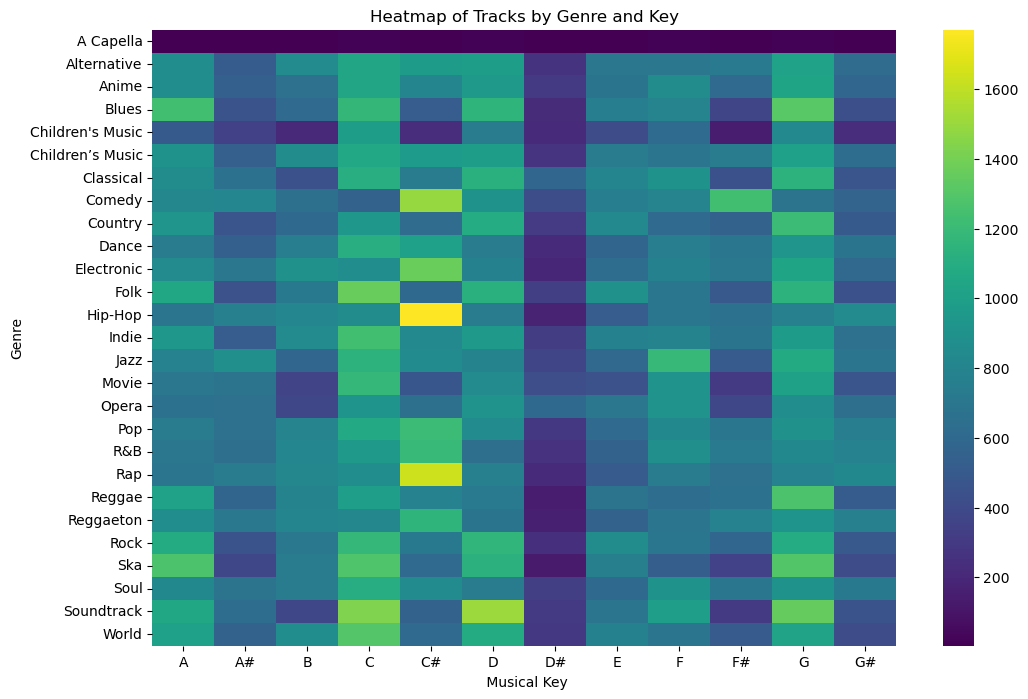

In [72]:
# 4C. Pivot Table — Track Count by Genre & Key 0 wide table
plt.figure(figsize=(12,8))
pivot = df.pivot_table(index="genre", columns="key", values="track_id", aggfunc="count", fill_value=0)
pivot.head()
# heat map
sns.heatmap(pivot, cmap="viridis")
plt.title("Heatmap of Tracks by Genre and Key")
plt.xlabel(" Musical Key")
plt.ylabel("Genre")
plt.show()

### Interpretation: Musical Key Distribution Across Genres

The above heatmap shows how tracks are distributed across musical keys for each genre within our dataset.
We can see that almost all genres have a low concentration in a few keys such as D#, hence we can assume that this key fails to be heavily utilized in Western popular music.

In contrast, genres such as Jazz, Hip-Hop and Soul display a broader spread across keys, highlighting their emphasis on musical complexity and creativity.
These patterns enables us to understand the correlation between music theory and genre identity.


## 4. Experiments With Different Plot Types

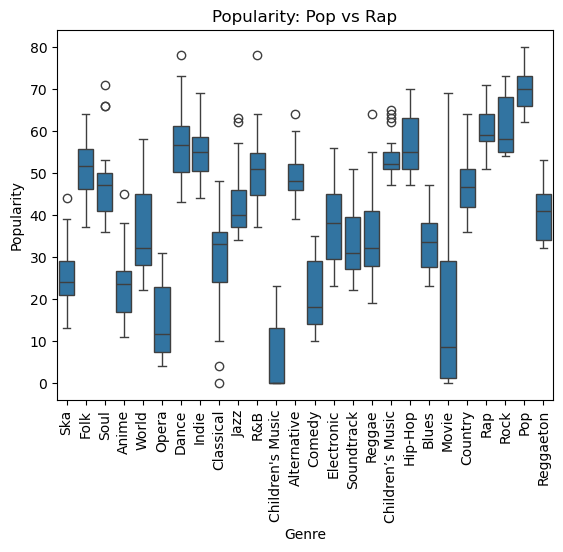

In [73]:
# 4A. Boxplot — Popularity by Two Genres
sns.boxplot(data=df.sample(500), x="genre", y="popularity")
plt.xticks(rotation=90)
plt.title("Popularity: Pop vs Rap")
plt.xlabel("Genre")
plt.ylabel("Popularity")
plt.show()


/tmp/ipykernel_132/1612315277.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


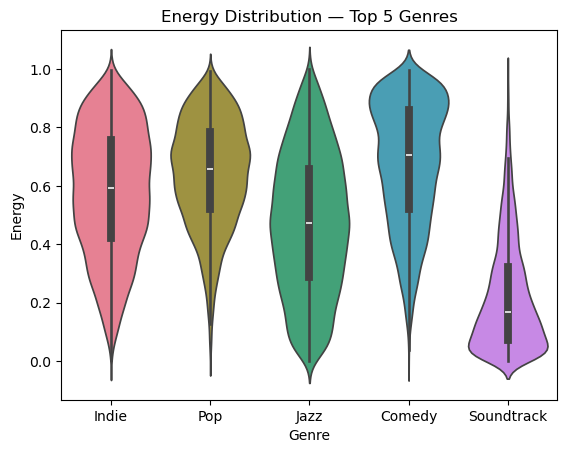

In [74]:
# 7. Violin Plot (high-quality visual)
sns.violinplot(
    data=df[df['genre'].isin(top5)], x="genre", y="energy", palette="husl") # husl changes the color
plt.title("Energy Distribution — Top 5 Genres")
plt.xlabel("Genre")
plt.ylabel("Energy")
plt.show()


### Interpretation: Energy Variation Within Genres

The violin plot highlights energy variation across the top 5 genres within our dataset.

Revealing that Pop and Indie tend to exhibit a higher average energy compared to counterparts while the Soundtrack genre shows a lower and more concentrated energy level.

Though similar to our initial boxplot analysis, the violin plot is beneficial due to its shape which reveals how diverse energy values are within each genre.

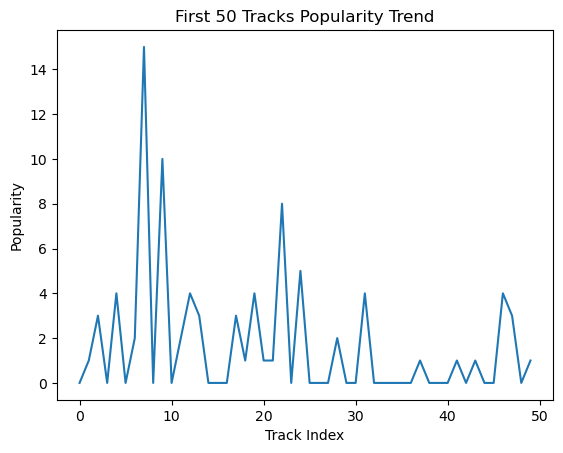

In [75]:
# 4C. Line Plot
df["popularity"].head(50).plot(kind="line")
plt.title("First 50 Tracks Popularity Trend")
plt.xlabel("Track Index")
plt.ylabel("Popularity")
plt.show()


### Interpretation: Popularity Fluctuation (Across Sample of 50 Tracks)

The above line plot visualizes popularity values for a small sample of tracks(50) revealing how popularity varies widely even across a short range of tracks, 
This reinforces the uneven distribution of attention in music streaming platforms.


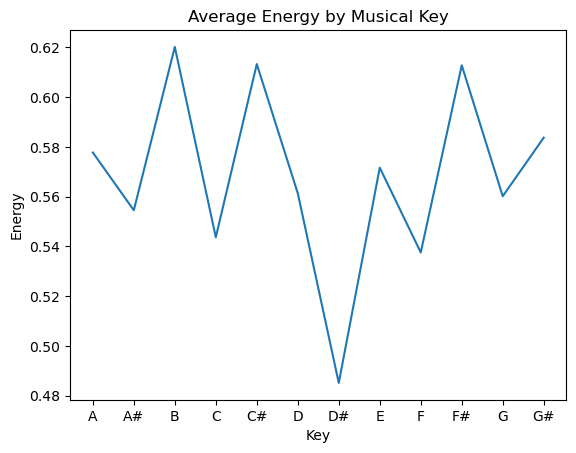

In [76]:
# 5B. Line Plot — Average Energy by Key
avg_energy_by_key = df.groupby("key")["energy"].mean()

plt.plot(avg_energy_by_key.index, avg_energy_by_key.values)
plt.title("Average Energy by Musical Key")
plt.xlabel("Key")
plt.ylabel("Energy")
plt.show()


### Interpretation: Correlation between  Energy and Musical Key

The above line plot explores the correlation between average energy values across musical keys.
This is done to analyze if different keys are associated with different tonal qualities revealing that some keys consistently produce higher energy levels(C#) while others contrast severely (D#) suggesting that more often than not structural musical patterns influence song dynamics.


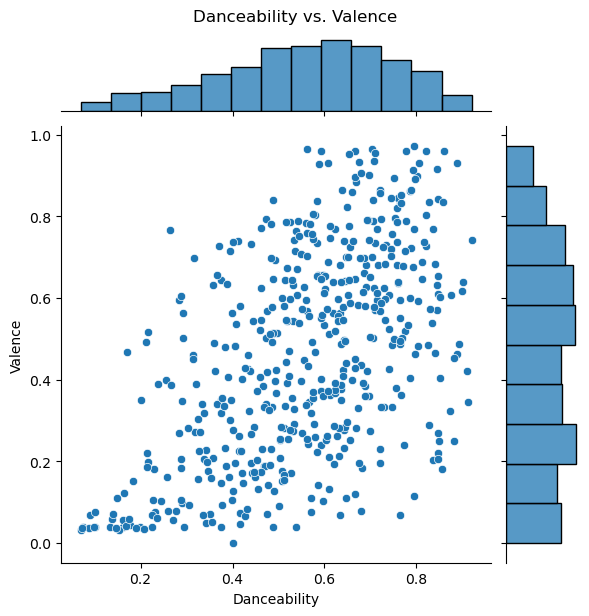

In [77]:
# Joint Plot (scatter + histogram)
sns.jointplot(
    data=df.sample(500),
    x="danceability",
    y="valence",
    kind="scatter"
)
plt.suptitle("Danceability vs. Valence", y=1.02)
plt.ylabel("Valence")
plt.xlabel("Danceability")
plt.show()

### Interpretation: Mood and Movement in Spotify Tracks

This joint plot combines a scatterplot with marginal distributions to examine danceability and valence.
Higher danceability is often associated with higher valence, indicating that upbeat, positive songs tend to be more danceable.

The marginal histograms show the most common ranges for each feature.
